<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Fall_2025/blob/main/Module%208/MidTerm_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MidTerm - 2 for the Fall 2025 Course "Machine Learning for Materials Science", University of Tennessee Knoxville, Department of Materials Science and Engineering.

- Instructor Sergei V. Kalinin

Special point:
- ChatGPT will augment your power as a coder
- If and only if you know what you want to accomplish!

# 1.Out-of-distribution effects

Explore the out of distribution effects in VAE.
- Build the VAE or AE denoiser
- Train it on the digits [0-5]
- Quantufy performance on the digits that it was trained on (e.g. vis SSID of ground truth vs reconstruction as a function of noise)
- Quantify performance for digits [6-9]

# 2.Explainable ML

- Build the classified for the fashion MNIST data set
- Use LIME or SHAP to explain the predictions

# 3.Molecular discovery

- We extract information from QM9 dataset, particularly from each molecule (given orignially in .xyz format) followed by computing features using rdkit and then combine those into a dataframe.
- Link to orginal dataset: http://quantum-machine.org/datasets/
- Link where we can find the functionalities represented by variables in the 'parser' code. For example 'mu' represents the dipole moment. https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.QM9.html

- Adapted from notebook prepared by Ayana Ghosh, research.aghosh@gmail.com

## Install RDkit and Selfies

In [1]:
!pip install rdkit
!pip install selfies --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 41.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd

import glob

import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors

import torch
from math import log
import matplotlib.pyplot as plt
from pandas import json_normalize

import selfies as sf

In [3]:
def parse_float(s: str) -> float:
    try:
        return float(s)
    except ValueError:
        base, power = s.split('*^')
        return float(base) * 10**float(power)

def parse_xyz(filename):
    """
    Parses QM9 specific xyz files.
    :param filename: str path to file
    :return:
    """
    num_atoms = 0
    scalar_properties = []
    atomic_symbols = []
    xyz = []
    charges = []
    harmonic_vibrational_frequencies = []
    smiles = ''
    inchi = ''
    with open(filename, 'r') as f:
        for line_num, line in enumerate(f):
            if line_num == 0:
                num_atoms = int(line)
            elif line_num == 1:
                scalar_properties = [float(i) for i in line.split()[2:]]
            elif 2 <= line_num <= 1 + num_atoms:
                atom_symbol, x, y, z, charge = line.split()
                atomic_symbols.append(atom_symbol)
                xyz.append([parse_float(x), parse_float(y), parse_float(z)])
                charges.append(parse_float(charge))
            elif line_num == num_atoms + 2:
                harmonic_vibrational_frequencies = [float(i) for i in line.split()]
            elif line_num == num_atoms + 3:
                smiles = line.split()[0]
            elif line_num == num_atoms + 4:
                inchi = line.split()[0]

    result = {
        'num_atoms': num_atoms,
        'atomic_symbols': atomic_symbols,
        'pos': torch.tensor(xyz),
        'charges': np.array(charges),
        'harmonic_oscillator_frequencies': harmonic_vibrational_frequencies,
        'smiles': smiles,
        'inchi': inchi
    }
    scalar_property_labels = ['A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'u0', 'u', 'h', 'g', 'cv']
    scalar_properties = dict(zip(scalar_property_labels, scalar_properties))
    result.update(scalar_properties)
    return result

## Download the data

In [4]:
!gdown https://drive.google.com/uc?id=1At3XHtaXXY3Qr4RIQ1Vua2_dRKoGyyEF

Downloading...
From (original): https://drive.google.com/uc?id=1At3XHtaXXY3Qr4RIQ1Vua2_dRKoGyyEF
From (redirected): https://drive.google.com/uc?id=1At3XHtaXXY3Qr4RIQ1Vua2_dRKoGyyEF&confirm=t&uuid=57422065-3b82-4a9d-8d60-788b776b08da
To: /content/dsgdb9nsd.xyz.tar.bz2
100% 86.1M/86.1M [00:01<00:00, 54.0MB/s]


Generate lists of SMILE strings and append with properties that we can directly retrieve from the QM9 dataset

What are SMILES and when were they invented (note that ChatGPT is unlikely to produce the correct citation - so Wikipedia can help)?

Answer:

In [5]:
!mkdir /content/Molecules
!tar -C Molecules -xvf /content/dsgdb9nsd.xyz.tar.bz2

Streaming output truncated to the last 5000 lines.
dsgdb9nsd_128886.xyz
dsgdb9nsd_128887.xyz
dsgdb9nsd_128888.xyz
dsgdb9nsd_128889.xyz
dsgdb9nsd_128890.xyz
dsgdb9nsd_128891.xyz
dsgdb9nsd_128892.xyz
dsgdb9nsd_128893.xyz
dsgdb9nsd_128894.xyz
dsgdb9nsd_128895.xyz
dsgdb9nsd_128896.xyz
dsgdb9nsd_128897.xyz
dsgdb9nsd_128898.xyz
dsgdb9nsd_128899.xyz
dsgdb9nsd_128900.xyz
dsgdb9nsd_128901.xyz
dsgdb9nsd_128902.xyz
dsgdb9nsd_128903.xyz
dsgdb9nsd_128904.xyz
dsgdb9nsd_128905.xyz
dsgdb9nsd_128906.xyz
dsgdb9nsd_128907.xyz
dsgdb9nsd_128908.xyz
dsgdb9nsd_128909.xyz
dsgdb9nsd_128910.xyz
dsgdb9nsd_128911.xyz
dsgdb9nsd_128912.xyz
dsgdb9nsd_128913.xyz
dsgdb9nsd_128914.xyz
dsgdb9nsd_128915.xyz
dsgdb9nsd_128916.xyz
dsgdb9nsd_128917.xyz
dsgdb9nsd_128918.xyz
dsgdb9nsd_128919.xyz
dsgdb9nsd_128920.xyz
dsgdb9nsd_128921.xyz
dsgdb9nsd_128922.xyz
dsgdb9nsd_128923.xyz
dsgdb9nsd_128924.xyz
dsgdb9nsd_128925.xyz
dsgdb9nsd_128926.xyz
dsgdb9nsd_128927.xyz
dsgdb9nsd_128928.xyz
dsgdb9nsd_128929.xyz
dsgdb9nsd_128930.xyz
dsgd

In [6]:
smiles = []
enthalpy = []
u0 = []
u = []
g = []
alpha = []
r2 = []
mu = []

#may need to change the path
filenames = glob.glob('/content/Molecules/*.xyz')

#may need to go through the full range
for fid in range(5000):
    x = parse_xyz(filenames[fid])
    smiles_loc = x['smiles']
    enthalpy_loc = x['h']
    dipole_moment = x['mu']
    homo_loc = x['homo']
    lumo_loc = x['lumo']
    gap_loc = x['gap']
    zpve_loc = x['zpve']
    u0_loc = x['u0']
    u_loc = x['u']
    g_loc = x['g']
    alpha_loc = x['alpha']
    r2_loc = x['r2']
    smiles.append(smiles_loc)
    mu.append(dipole_moment)
    enthalpy.append(enthalpy_loc)
    u0.append(u0_loc)
    u.append(u_loc)
    g.append(g_loc)
    alpha.append(alpha_loc)
    r2.append(r2_loc)

Let's compute few basic features and put together a dataset. Features we compute:
- molecular weight,
- topological polar surface area,
- molar log P,
- number of hydrogen bond donors,
- acceptors,
- valence electrons,
- maximum partial charge,
- minimum partial charge,
- number of rotatable bonds,
- number of ring counts,
- number of stereocenters

In [7]:
mol_wt, tpsa, logp_ml, hbd, hba  = [], [], [], [], []
vale, partialcg_max, partialcg_min, rotbd, ringct, stereoct = [], [], [], [], [], []

for i in range(len(smiles)):
    m = Chem.MolFromSmiles(smiles[i])
    mol_wt_l = Descriptors.ExactMolWt(m)
    tpsa_l, logp_l = Descriptors.TPSA(m), Descriptors.MolLogP(m)
    hbd_l, hba_l = Descriptors.NumHDonors(m), Descriptors.NumHAcceptors(m)
    vale_l = Descriptors.NumValenceElectrons(m),
    partialcharge_max_l, partialcharge_min_l = Descriptors.MaxPartialCharge(m), Descriptors.MinPartialCharge(m)
    rotbd_l = Descriptors.NumRotatableBonds(m)
    ring_ct, stereo_cent = Descriptors.RingCount(m), rdMolDescriptors.CalcNumAtomStereoCenters(m)

    mol_wt.append(mol_wt_l)
    tpsa.append(tpsa_l)
    logp_ml.append(logp_l)
    hbd.append(hbd_l)
    hba.append(hba_l)
    vale.append(vale_l)
    partialcg_max.append(partialcharge_max_l)
    partialcg_min.append(partialcharge_min_l)
    rotbd.append(rotbd_l)
    ringct.append(ring_ct)
    stereoct.append(stereo_cent)

New dataset with few features with SMILE strings

In [8]:
df = pd.DataFrame({'smiles': smiles, 'mole_logp': logp_ml,'tpsa': tpsa, 'mol_wt' : mol_wt,
                   'hbd': hbd, 'hba':hba, 'valencee':vale, 'max_partialcharge':partialcg_max, 'min_partialcharge':partialcg_min,
                   'rotatablebd':rotbd, 'ringct':ringct, 'stereocent': stereoct, 'dipole_moment':mu})

In [9]:
df

,smiles,mole_logp,tpsa,mol_wt,hbd,hba,valencee,max_partialcharge,min_partialcharge,rotatablebd,ringct,stereocent,dipole_moment
0,N#CCCC12CC1CC2,2.09028,23.79,121.089149,0,1,"(48,)",0.062146,-0.198347,2,2,2,4.1425
1,OCC1(CC=CC1)C=O,0.51400,37.30,126.068080,1,2,"(50,)",0.128565,-0.395323,2,1,0,2.8777
2,NC(=O)N1C=CC(O)=N1,-0.48450,81.14,127.038176,2,4,"(48,)",0.339053,-0.492204,0,1,0,2.4783
3,O=C1C2CCC(C2)C1=O,0.55450,34.14,124.052429,0,2,"(48,)",0.201265,-0.290571,0,2,2,4.6941
4,CC12CC1C(C)(C)C2O,1.41330,20.23,126.104465,1,1,"(52,)",0.064999,-0.391981,0,2,3,1.2226
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CN=C1NC(C)=NO1,-0.15838,54.18,113.058912,1,3,"(44,)",0.319672,-0.315631,0,1,0,3.8557
4996,CC1(O)CCCC11CO1,0.69030,32.76,128.083730,1,2,"(52,)",0.119807,-0.387073,0,2,2,2.8954
4997,CC(C#C)C1(CC1)C#C,1.66910,0.00,118.078250,0,0,"(46,)",0.044709,-0.119766,1,1,1,0.8773
4998,OC1C2C3CC2(O)C13O,-1.52720,60.69,128.047344,3,3,"(50,)",0.123121,-0.389577,0,5,5,1.8528


## Convert SMILEs to SELFIEs

As an excercise, read the SELFIES paper (https://github.com/aspuru-guzik-group/selfies) and describe the difference between SMILES and SELFIEs

Answer:

In [10]:
smiles

['N#CCCC12CC1CC2',
 'OCC1(CC=CC1)C=O',
 'NC(=O)N1C=CC(O)=N1',
 'O=C1C2CCC(C2)C1=O',
 'CC12CC1C(C)(C)C2O',
 'CC1(C)COCC2NC12',
 'CC12CC3(CC3)C1(C)O2',
 'O=CC(OCC#C)C#N',
 'CC12CC(C1)C1OCC21',
 'CC12NC1CNC2=O',
 'OC1CNC(=O)C=CC1',
 'COCC1=NC2CC2N1',
 'COCC(O)CC#N',
 'OC1CC11CC(=O)CO1',
 'CC1(CC(=O)CO)CC1',
 'N=COC1CC1N1CC1',
 'CC12NC3C1OCOC23',
 'CC(=O)C1CCC1(C)O',
 'CCC(C)C(C)CC#C',
 'CC1C2C(C=O)C1C2=O',
 'CC1=C(OC(=O)O1)C=O',
 'O=C1OCCCCO1',
 'CC1OC(C=O)C11CC1',
 'CC1OC11COCOC1',
 'O=C1NCC(N1)C1CC1',
 'CC12C3CC4CC1C4C23',
 'CC1=NC=C(N)C(O)=C1',
 'OC1CC2(CO2)C1',
 'CC#CC12CC3CN1C23',
 'CC#CC(O)C1CCO1',
 'COC12CC1COCC2',
 'C1NC1C12OC1C1CC21',
 'N=C1ON=NC=NC1=O',
 'O=CC1=CNC2(CC2)C1',
 'CC12CCC1OC=NC2',
 'NC1=NC(=N)N=CN=C1',
 'C1C2N1CC21CCO1',
 'CCC1(C)CC1C#C',
 'N1C=NC=CC=CN=C1',
 'COCCC1(CN1)C=O',
 'CC(C)C12OC3CC1C23',
 'CC(O)C1OCCC1O',
 'CCN1N=CC(=N1)C#N',
 'CC(C)(O)C1CC=CC1',
 'CCC1(CO1)C1CCC1',
 'O=C1CC=CCN=CO1',
 'OCCCC1=NON=N1',
 'OC1C=CC=CC=C1',
 'CCC(CC#N)C(C)C',
 'CCCC12OCC1C2C'

The SELFIES have some limitations on acceptable bonding. So we refine the data set to remove the molecules that do not fit into supported semantic constraints.

In [11]:
selfies_dataset = []
error_smiles = []

for i in range(len(smiles)):
    try:
        local_sf = sf.encoder(smiles[i])
        selfies_dataset.append(local_sf)
    except Exception as e:
        print(f"Error encoding SMILES at index {i}: {e}")
        error_smiles.append(smiles[i])  # Store the SMILES string that caused the error
        continue  # Skip to the next iteration

Error encoding SMILES at index 99: input violates the currently-set semantic constraints
	SMILES: O=N(=O)C1=NOC=C1
	Errors:
	[N with 5 bond(s) - a max. of 3 bond(s) was specified]

Error encoding SMILES at index 114: input violates the currently-set semantic constraints
	SMILES: NC1=C(N=CN1)N(=O)=O
	Errors:
	[N with 5 bond(s) - a max. of 3 bond(s) was specified]

Error encoding SMILES at index 603: input violates the currently-set semantic constraints
	SMILES: NC1=CC=C(O1)N(=O)=O
	Errors:
	[N with 5 bond(s) - a max. of 3 bond(s) was specified]

Error encoding SMILES at index 1400: input violates the currently-set semantic constraints
	SMILES: NC1=C(ON=N1)N(=O)=O
	Errors:
	[N with 5 bond(s) - a max. of 3 bond(s) was specified]

Error encoding SMILES at index 2442: input violates the currently-set semantic constraints
	SMILES: CC1=CC=C(O1)N(=O)=O
	Errors:
	[N with 5 bond(s) - a max. of 3 bond(s) was specified]

Error encoding SMILES at index 2710: input violates the currently-set semanti

Let's see what these molecules are....

In [12]:
error_smiles_set = set(error_smiles)
error_smiles_set

{'CC1=CC=C(O1)N(=O)=O',
 'CC1=NOC(=N1)N(=O)=O',
 'NC1=C(N=CN1)N(=O)=O',
 'NC1=C(ON=N1)N(=O)=O',
 'NC1=CC(=CO1)N(=O)=O',
 'NC1=CC=C(O1)N(=O)=O',
 'NC1=COC(=C1)N(=O)=O',
 'NC1=NC(=CO1)N(=O)=O',
 'O=N(=O)C1=NNC=C1',
 'O=N(=O)C1=NOC=C1'}

... how many of them are there

In [13]:
df['smiles'].isin(error_smiles_set).sum()

np.int64(10)

And remove them from the dataframe

In [14]:
df_filtered = df[~df['smiles'].isin(error_smiles_set)]
df_filtered.tail(5)

,smiles,mole_logp,tpsa,mol_wt,hbd,hba,valencee,max_partialcharge,min_partialcharge,rotatablebd,ringct,stereocent,dipole_moment
4995,CN=C1NC(C)=NO1,-0.15838,54.18,113.058912,1,3,"(44,)",0.319672,-0.315631,0,1,0,3.8557
4996,CC1(O)CCCC11CO1,0.69030,32.76,128.083730,1,2,"(52,)",0.119807,-0.387073,0,2,2,2.8954
4997,CC(C#C)C1(CC1)C#C,1.66910,0.00,118.078250,0,0,"(46,)",0.044709,-0.119766,1,1,1,0.8773
4998,OC1C2C3CC2(O)C13O,-1.52720,60.69,128.047344,3,3,"(50,)",0.123121,-0.389577,0,5,5,1.8528
4999,CC1(CO)OC11COC1,-0.46340,41.99,130.062994,1,3,"(52,)",0.146287,-0.393262,1,2,1,0.7032


Now, let's generate one-hot encodings.

In [15]:
#for producing corresponding one-hot vectors
alphabet = sf.get_alphabet_from_selfies(selfies_dataset)
alphabet.add("[nop]")  # [nop] is a special padding symbol
alphabet = list(sorted(alphabet))

pad_to_len = max(sf.len_selfies(s) for s in selfies_dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}

labels = []
one_hot_vectors = []
for i in range(len(selfies_dataset)):

  label, one_hot = sf.selfies_to_encoding(selfies=selfies_dataset[i], vocab_stoi=symbol_to_idx,
                                          pad_to_len=pad_to_len, enc_type="both")
  labels.append(label)
  one_hot_vectors.append(one_hot)

np.array(one_hot_vectors).shape

(4990, 21, 27)

Explore the code segment above. What is:
- alphabet
- symbol_to_idx
- what are the dimensionalities of the np.array(one_hot_vectors).shape

Answer:

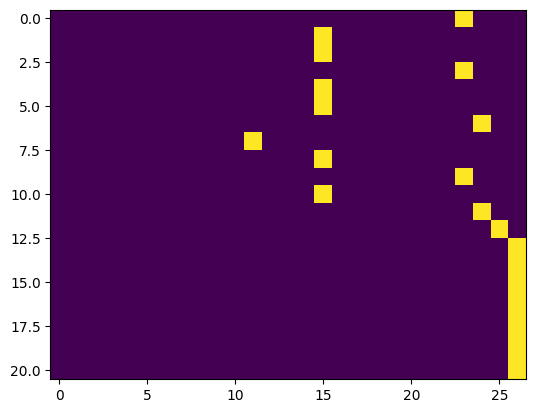

In [16]:
plt.imshow(np.array(one_hot_vectors)[310,:,:])

Now, let's explore the properties of the latent space of this dataset. Using ChaGPT:
- Write the AE using the encoded smiles as an input with 2D latent space
-  Visualize the latent distribution and representation
- Experiment with difefrent attributes from data frame as labels, and see how they are distirbuted in latent space

Do the same with the VAE, also with 2D latent space

Write the VAE with the 10D latent space. Suggest an approach to visualize the latent space

Describe the difference between AE and VAE latent distirbutions

Answer:

Explore the variability of
- dipole momentum,
- number of rings
- mole log P over latent spaces.
What conclusions can you make?

# 4.Causal Discovery

In [17]:
!gdown https://drive.google.com/file/d/1bSE7WuvPHYWLo-s2KZonlMHPYBY8k3kr/view?usp=sharing --fuzzy

Downloading...
From: https://drive.google.com/uc?id=1bSE7WuvPHYWLo-s2KZonlMHPYBY8k3kr
To: /content/composition_features_pymatgen.csv
100% 164k/164k [00:00<00:00, 139MB/s]


In [18]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("composition_features_pymatgen.csv")

# Display the first 5 rows
display(df.head())

,Composition,CTE Value,Al3_oct,Al3_tet,Ba2_oct,Be3_oct,Ca2_multi,Ca2_oct,Ce-22_oct,Ce3_multi,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,Y0.5Yb0.5Ta0.5Nb0.5ZrO7,0.000011,0.0,0,0,0,0.0,0.0,0,0.0,...,0.000000,0.000000,0.000000,0.0,12.0,229.0,217.0,71.650000,83.510000,12.0
1,Y0.4175Yb0.4175Ta0.4175Nb0.4175ZrO6.67,0.000011,0.0,0,0,0,0.0,0.0,0,0.0,...,0.000000,0.000000,0.000000,0.0,12.0,229.0,217.0,68.548500,80.762568,12.0
2,Al2O3Y0.6Er0.6Yb0.6Ho0.6Lu0.6Al5O12,0.000008,7.0,0,0,0,0.0,0.0,0,0.0,...,0.002247,0.000054,0.000105,0.0,12.0,225.0,213.0,94.224000,98.668800,12.0
3,Al2O3Y3Al5O12,0.000008,7.0,0,0,0,0.0,0.0,0,0.0,...,0.000000,0.000000,0.000000,0.0,12.0,225.0,213.0,93.480000,97.776000,12.0
4,La0.4Nd0.4Sm0.4Eu0.4Gd0.4Zr2O7,0.000013,0.0,0,0,0,0.0,0.0,0,0.0,...,0.000000,0.000000,0.000000,0.0,12.0,229.0,217.0,78.453109,84.564605,12.0


The dataset consists of the multiple compositional features and CTE (coeffitient of thermal expansion) values for the 214 composition.

We train a regression model to predict the CTE value from the feature vectors and identify the ten most influential features using SHAP analysis, thereby reducing computational complexity for subsequent analyses.

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import shap

# --- 1. Prepare data ---
target = "CTE Value"
X = df.select_dtypes(include=[np.number]).drop(columns=[target], errors="ignore")
y = df[target].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. Train model ---
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(n_estimators=500, max_features="sqrt", n_jobs=-1, random_state=42))
])
model.fit(X_train, y_train)

# --- 3. Evaluate ---
mse = mean_squared_error(y_test, model.predict(X_test))
print(f"Test MSE: {mse:.10f}")

# --- 4. SHAP feature importance ---
rf = model.named_steps["rf"]
X_test_imp = pd.DataFrame(model.named_steps["imputer"].transform(X_test), columns=X.columns)

explainer = shap.TreeExplainer(rf)
shap_vals = explainer(X_test_imp).values
importance = pd.Series(np.abs(shap_vals).mean(axis=0), index=X.columns).sort_values(ascending=False)

print("\nTop 10 important features:")
print(importance.head(10).round(10))

# Optional plot
# shap.summary_plot(shap_vals, X_test_imp)


Test MSE: 0.0000000000

Top 10 important features:
MagpieData mean GSbandgap          2.949000e-07
MagpieData mean Row                2.913000e-07
MagpieData avg_dev GSbandgap       2.661000e-07
Avg Ionic Radius (Å)               2.548000e-07
MagpieData mean Number             2.230000e-07
MagpieData mean AtomicWeight       2.092000e-07
Ionic Size Mismatch (%)            1.930000e-07
MagpieData maximum GSbandgap       1.890000e-07
MagpieData maximum AtomicWeight    1.795000e-07
MagpieData mean CovalentRadius     1.714000e-07
dtype: float64


In [20]:
# --- 1) Top-10 feature importance as a DataFrame ---
top10_importance_df = (
    importance.head(10).rename("mean_abs_shap")
         .reset_index()
         .rename(columns={"index": "feature"})
)
top10_importance_df
# --- 2) Original df with only the top-10 features (+ composition, CTE if present) ---
top10_features = importance.head(10).index.tolist()
cols_keep = [c for c in ["composition", "CTE"] if c in df.columns] + top10_features
df_top10_features = df[cols_keep].copy()
print(df_top10_features.shape, "rows x cols")

(118, 10) rows x cols


In [21]:
#this is fully prepared dataset
# Create a list of columns to keep: the target column and the top 10 features
columns_to_keep = ["CTE Value"] + top10_features

# Create the new DataFrame by selecting these columns from the original DataFrame
df_important = df[columns_to_keep].copy()

# Display the head of the new DataFrame to verify
display(df_important.head())

,CTE Value,MagpieData mean GSbandgap,MagpieData mean Row,MagpieData avg_dev GSbandgap,Avg Ionic Radius (Å),MagpieData mean Number,MagpieData mean AtomicWeight,Ionic Size Mismatch (%),MagpieData maximum GSbandgap,MagpieData maximum AtomicWeight,MagpieData mean CovalentRadius
0,0.000011,0.0,3.000000,0.0,1.1484,20.750000,47.112685,15.62,0.0,180.94788,99.250000
1,0.000011,0.0,2.947100,0.0,1.1532,19.964900,45.146153,15.35,0.0,180.94788,97.654800
2,0.000008,0.0,2.736000,0.0,1.0679,16.000000,35.613254,23.99,0.0,174.96680,96.160000
3,0.000008,0.0,2.640000,0.0,1.0698,13.120000,27.823173,23.91,0.0,88.90585,96.280000
4,0.000013,0.0,3.273145,0.0,1.1683,23.496901,53.790845,13.24,0.0,157.25000,110.195361


### part 1. Causal discovery through the data

In [22]:
!pip install gcastle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.4/214.4 kB 4.6 MB/s eta 0:00:00


`gCastle` provides a data-driven framework to learn causal relationships directly from observational data.


Learn more: https://doi.org/10.48550/arXiv.2111.15155

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from castle.algorithms import PC, Notears, GOLEM

In [24]:
data = df_important

names = data.columns.tolist()
X = StandardScaler().fit_transform(data)
print(f"Loaded {len(names)} variables. Matrix shape: {X.shape}")

Loaded 11 variables. Matrix shape: (118, 11)


In [25]:
#preparing data
data = df_important.select_dtypes(include=[np.number]).dropna().copy()
assert target in data.columns, f"Target '{target}' must be numeric."

names = data.columns.tolist()
X = StandardScaler().fit_transform(data)
print(f"Loaded {len(names)} variables. Matrix shape: {X.shape}")

Loaded 11 variables. Matrix shape: (118, 11)


Learn possible causal structures among the variables applying different causal discovery algorithms (at least 3) by gcastle.

In [26]:
#your code

visualize learned adjacency matrices as heatmaps

In [27]:
#your code

identify direct casual parent for the target property `CTE Value` for each method


In [28]:
#your code

optional: build DAG graph

In [29]:
#your code

Compare the inferred causal relationships obtained from the three methods and briefly discuss the observed causal structures, including possible reasons for the differences between the results.

*your text / code*

### part-2. LLM-based causal analysis (GEMINI)

In [30]:
!pip install -q google-generativeai tqdm

In [31]:
import os, re, json, time
from tqdm import tqdm
import google.generativeai as genai

genai.configure(api_key='')

# Pick a model (flash = cheaper/faster, pro = stronger)
MODEL_NAME = "models/gemini-2.5-flash"  # or "gemini-1.5-pro"
model = genai.GenerativeModel(MODEL_NAME)

We can employ LLM to infer the most plausible causal direction between two variables based on physical reasoning and domain knowledge, rather than numerical data.

An example of the causual pair establishing:

In [32]:
import json, re

def causal_pair(model, A_name, A_desc, B_name, B_desc):
    """
    Ask an LLM to decide the direct causal direction between two variables.
    Returns (label, reason):
      1 = A → B,  -1 = B → A,  0 = unknown/ambiguous
    """
    prompt = f"""
You are a careful physicist. Decide the plausible DIRECT CAUSAL direction
between two material-related variables using physics/common sense ONLY.
Reply ONLY with JSON: {{"label": [1,-1,0], "reason": "<=30 words"}}.

A = "{A_name}" — {A_desc or "(no description)"}
B = "{B_name}" — {B_desc or "(no description)"}
"""
    # Query the model
    resp = model.generate_content(prompt)
    text = (resp.text or "").strip()

    # Try to extract JSON
    try:
        obj = json.loads(text)
    except Exception:
        match = re.search(r"\{.*\}", text, re.S)
        obj = json.loads(match.group(0)) if match else {"label": 0, "reason": "no valid response"}

    # Validate outputs
    label = int(obj.get("label", 0)) if obj.get("label") in [1, -1, 0] else 0
    reason = str(obj.get("reason", "")).strip()
    return label, reason


# --- Example usage ---
A = ("Avg Band Gap Deviation", "Deviation of elemental band gaps in composition")
B = ("Avg Ionic Radius (Å)", "Mean ionic radius of constituent elements")

label, reason = causal_pair(model, *A, *B)
print(f"Label: {label}  (1=A→B, -1=B→A, 0=unknown)")
print("Reason:", reason)

DefaultCredentialsError: 
  No API_KEY or ADC found. Please either:
    - Set the `GOOGLE_API_KEY` environment variable.
    - Manually pass the key with `genai.configure(api_key=my_api_key)`.
    - Or set up Application Default Credentials, see https://ai.google.dev/gemini-api/docs/oauth for more information.

We now return to the CTE examples.  Below are the physics-aware descriptions provided for Gemini prompting (top 10 from SHAP).

In [ ]:
# Physics-aware descriptions for your Gemini prompting

var_info = {
    "MagpieData mean GSbandgap": "Mean elemental ground-state band gap of constituents (eV).",
    "MagpieData mean Row": "Mean periodic table row (principal shell index) of elements.",
    "MagpieData avg_dev GSbandgap": "Average deviation of elemental band gaps (composition heterogeneity).",
    "Avg Ionic Radius (Å)": "Average ionic radius of species in composition (Å).",
    "MagpieData mean Number": "Mean atomic number Z of constituent elements.",
    "MagpieData mean AtomicWeight": "Mean atomic mass of constituent elements (amu).",
    "Ionic Size Mismatch (%)": "Percent mismatch among ionic radii (size disparity).",
    "MagpieData maximum GSbandgap": "Maximum elemental ground-state band gap present (eV).",
    "MagpieData maximum AtomicWeight": "Maximum elemental atomic mass present (amu).",
    "MagpieData mean CovalentRadius": "Mean covalent radius of constituent elements (Å).",
}

In [ ]:
var_names = list(var_info.keys())
print(f"{len(var_names)} variables:\n", var_names)

.. Design a structured prompt that instructs a language model to act as a physicist and determine the plausible causal direction between two variables using physical reasoning only.
The prompt must clearly define the model’s role, input format, response format (strict JSON), and interpretation of causal labels.

The prompt will be use in method as:
`prompt = prompt_template.format(ai=ai, ad=adesc or "(no desc)", bj=aj, bd=bdesc or "(no desc)")

In [ ]:
#improve the prompt below
prompt_template = f"""\ WRITE YOUR PROMPT HERE


Task: Using physics common sense (no data), is there a plausible direct causal relation?
Respond as compact JSON, e.g. {{"label":1,"reason":"..."}} with NO extra text.
"""



In [ ]:
import json, re, time

def ask_gemini_for_pair(ai, aj, adesc, bdesc, prompt_template, max_retries=3, sleep=1.2):
    """
    Query the Gemini model to decide the plausible causal direction between two variables.

    Parameters
    ----------
    ai, aj : str
        Names of the two variables (A and B).
    adesc, bdesc : str
        Optional short descriptions of the variables.
    prompt_template : str
        Prompt template containing placeholders {ai}, {ad}, {bj}, {bd}.
    max_retries : int, optional
        Number of retries if model call or parsing fails.
    sleep : float, optional
        Pause between retries (seconds).

    Returns
    -------
    (label, reason) : tuple
        label ∈ {1, -1, 0} → (A→B, B→A, or unknown),
        reason : short explanation string.
    """

    # Fill in the prompt template with variable names and descriptions
    prompt = prompt_template.format(
        ai=ai, ad=adesc or "(no description)",
        bj=aj, bd=bdesc or "(no description)"
    )

    for _ in range(max_retries):
        try:
            # Send prompt to model and retrieve text output
            resp = model.generate_content(prompt)
            text = (resp.text or "").strip()

            # --- Try to parse the model output as JSON ---
            try:
                obj = json.loads(text)
            except Exception:
                # Fallback: extract the first {...} block if extra text is returned
                m = re.search(r"\{.*\}", text, flags=re.S)
                obj = json.loads(m.group(0)) if m else {}

            # --- Validate and clean fields ---
            label = int(obj.get("label", 0)) if obj.get("label") in [1, -1, 0] else 0
            reason = str(obj.get("reason", "")).strip()

            return label, reason  # success → return early

        except Exception:
            # Wait and retry in case of API or parsing issues
            time.sleep(sleep)

    # If all retries fail, return default
    return 0, "no_response"


In [ ]:
# 3) Query all unordered pairs and assemble an adjacency
#    A[i,j] = +1 (i→j), -1 (j→i), 0 (unknown); enforce skew-symmetry

n = len(var_names)
A = np.zeros((n, n), dtype=int)
reasons = {}  # (i,j) -> reason for i<j

pairs = [(i, j) for i in range(n) for j in range(i+1, n)]

for i, j in tqdm(pairs, desc="Gemini causal pairs"):
    ai, aj = var_names[i], var_names[j]
    ad, bd = var_info[ai], var_info[aj]
    label, reason = ask_gemini_for_pair(ai, aj, ad, bd, prompt_template)
    # Enforce antisymmetry
    if label == 1:       # i -> j
        A[i, j] = 1;  A[j, i] = -1
    elif label == -1:    # j -> i
        A[i, j] = -1; A[j, i] = 1
    else:                # unknown
        A[i, j] = 0;  A[j, i] = 0
    reasons[(i, j)] = reason

adj_df = pd.DataFrame(A, index=var_names, columns=var_names)
adj_df.head()

Acquired reasons;

In [ ]:
reasons

In [ ]:
import networkx as nx

G = nx.DiGraph()
G.add_nodes_from(var_names)

for i in range(n):
    for j in range(n):
        if A[i, j] == 1:
            G.add_edge(var_names[i], var_names[j])

# Layout & draw
pos = nx.kamada_kawai_layout(G)
plt.figure(figsize=(max(8, 0.6*n + 4), max(6, 0.5*n + 2)))
nx.draw_networkx_nodes(G, pos, node_color="white", edgecolors="black")
nx.draw_networkx_labels(G, pos, font_size=10,
                        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=0.2))
if G.number_of_edges():
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=14)
plt.title("Gemini-derived causal DAG (unknown edges omitted)")
plt.axis("off"); plt.tight_layout(); plt.show()


Choose two nodes in the DAG and analyze the observed dependency between them. Determine whether the relationship is direct or mediated through other variables, and assess whether the inferred causal direction is physically adequate and reasonable.

*your text/code*